<a href="https://colab.research.google.com/github/chang110732/wed_2026_bigdatacomputing/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok joblib

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. 데이터 가져오기
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)

# 컬럼 이름 앞뒤에 있는 모든 공백 제거하기
df.columns = df.columns.str.strip()

# 사용할 변수 이름 지정
target_col = 'Life expectancy'
feature_cols = ['Adult mortality', 'BMI', 'GDP']

# 결측치(NaN) 있는 행들 정리
df = df.dropna(subset=[target_col] + feature_cols)

# 변수 나누기
X = df[feature_cols]
y = df[target_col]

# 데이터 분할 (8:2 비율)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 과대적합 확인을 위해 훈련 데이터는 50개 샘플만 무작위 추출
X_train = X_train_full.sample(n=50, random_state=42)
y_train = y_train_full.loc[X_train.index]

# 2. 파이프라인 모델 3개 생성
# 기본 선형 회귀
m1 = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
# 3차 다항 회귀 (규제 없음)
m2 = Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=3)), ('regressor', LinearRegression())])
# 3차 다항 회귀 + 릿지 규제
m3 = Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=3)), ('regressor', Ridge(alpha=1.0))])

# 모델 학습 진행
m1.fit(X_train, y_train)
m2.fit(X_train, y_train)
m3.fit(X_train, y_train)

# 외부에서 사용할 수 있도록 pkl 파일로 모델 저장
joblib.dump(m1, 'model_linear.pkl')
joblib.dump(m2, 'model_poly.pkl')
joblib.dump(m3, 'model_ridge.pkl')

# 성능 지표 계산용 함수
def get_info(model, name):
    p_tr, p_te = model.predict(X_train), model.predict(X_test)
    comp = model.named_steps['poly'].n_output_features_ if 'poly' in model.named_steps else X_train.shape[1] + 1
    return {
        'Model': name,
        'Train R2': r2_score(y_train, p_tr),
        'Test R2': r2_score(y_test, p_te),
        'Train MSE': mean_squared_error(y_train, p_tr),
        'Test MSE': mean_squared_error(y_test, p_te),
        'Complexity': comp
    }

# 결과를 데이터프레임으로 묶어서 csv 파일로 보관
pd.DataFrame([
    get_info(m1, 'Linear'),
    get_info(m2, 'Poly (Degree=3)'),
    get_info(m3, 'Ridge (Alpha=1.0)')
]).to_csv('metrics.csv', index=False)

print("데이터 처리 및 모델 저장 완료")

데이터 처리 및 모델 저장 완료


In [7]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 웹페이지 넓게 쓰기 설정
st.set_page_config(layout="wide")
st.title("기대수명 예측 및 규제 모델 성능 비교")
st.write("WHO 기대수명 데이터셋을 활용한 회귀 모델 대시보드")

# 2단계에서 저장해둔 데이터랑 모델들 불러오기
metrics_df = pd.read_csv('metrics.csv')
models = {
    'Linear': joblib.load('model_linear.pkl'),
    'Poly': joblib.load('model_poly.pkl'),
    'Ridge': joblib.load('model_ridge.pkl')
}

# --- [조건 3] 모델 성능 비교 화면 ---
st.header("1. 모델 성능 비교 (과대적합 관찰)")

st.subheader("성능 평가지표 테이블")
st.dataframe(metrics_df)

st.subheader("Test R² 점수 비교 차트")
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x='Model', y='Test R2', data=metrics_df, ax=ax, palette='Set2')
ax.set_ylim(-1.5, 1.0) # 오버피팅으로 점수 떨어지는 것 대비
st.pyplot(fig)

st.markdown("---")

# 실시간 예측 UI 구성
st.header("2. 실시간 기대수명 예측")

# 사이드바에 슬라이더 배치
st.sidebar.header("변수 조정 슬라이더")
am = st.sidebar.slider("Adult mortality", 1, 750, 150)
bmi = st.sidebar.slider("BMI", 1.0, 80.0, 30.0)
gdp = st.sidebar.slider("GDP", 1, 120000, 5000)

# 드롭다운으로 모델 선택
sel_model = st.selectbox("예측에 사용할 모델을 선택하세요", ["Linear", "Poly", "Ridge"])

# 예측용 데이터프레임 만들기 (2단계에서 쓴 컬럼명과 똑같이 일치시킴)
in_df = pd.DataFrame([{'Adult mortality': am, 'BMI': bmi, 'GDP': gdp}])

# 선택한 모델로 예측값 계산
pred = models[sel_model].predict(in_df)[0]

# 결과 출력
st.subheader(f"{sel_model} 모델의 예상 기대수명: {pred:.2f} 세")

Writing app.py


In [8]:
from pyngrok import ngrok
import os

ngrok.set_auth_token("3FGUWzZwMr2vJFeOMhMTx5ngMLy_6azbeGc277K7wshaASyTi")

# 스트림릿 서버 백그라운드 구동
os.system("nohup streamlit run app.py --server.port 8501 &")

# 외부 공인 URL로 터널링 연결
public_url = ngrok.connect(8501, "http")
print(f"외부 접속 링크 (여기로 접속해서 화면 캡처하세요): {public_url}")

외부 접속 링크 (여기로 접속해서 화면 캡처하세요): NgrokTunnel: "https://dodgy-poppy-favorably.ngrok-free.dev" -> "http://localhost:8501"


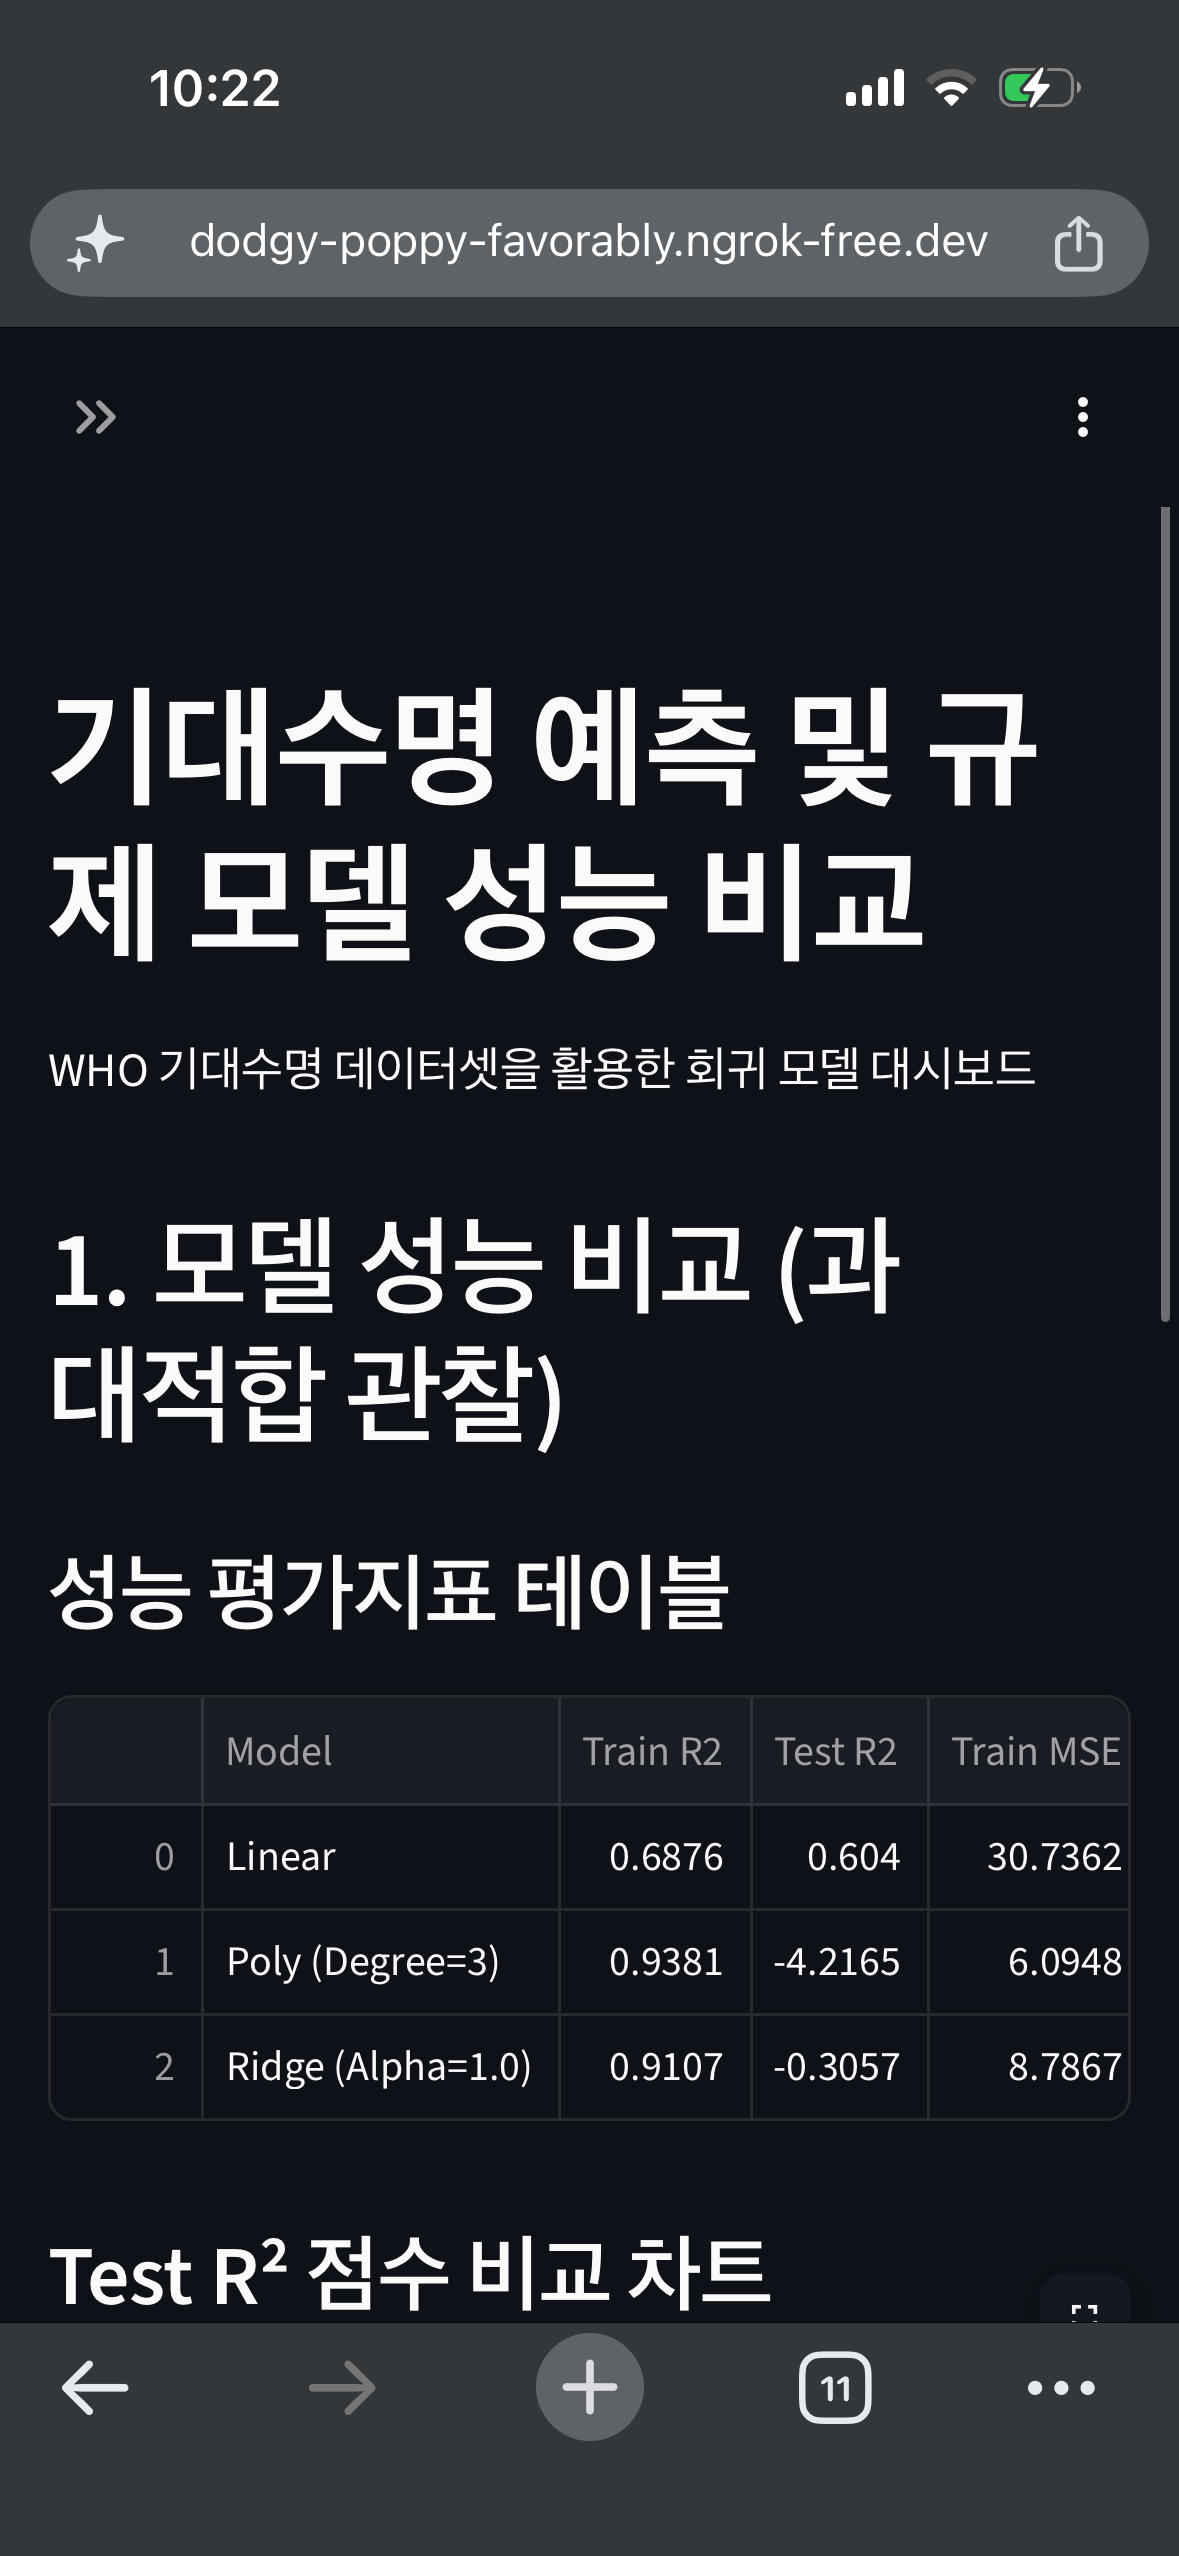